# Multi-Pass FFT window deformation implementation 

In [2]:
from openpiv import windef, tools, validation
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
frame_a = tools.imread("B001_1.tif")
frame_b = tools.imread("B001_2.tif")

#Make sure images have the same size
print("Frame A shape:", frame_a.shape)
print("Frame B shape:", frame_b.shape)

Frame A shape: (512, 512)
Frame B shape: (512, 512)


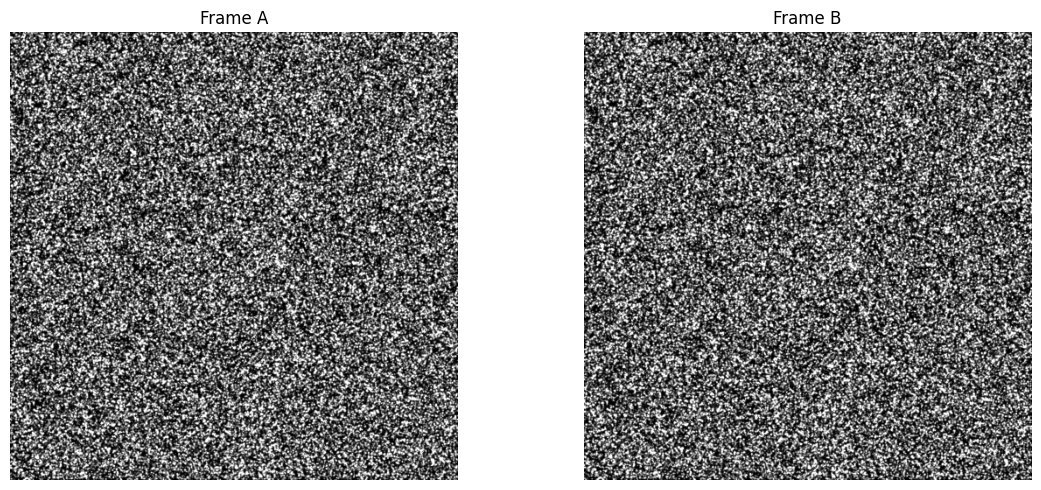

In [4]:
#Create a figure containing both of the image =s 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(frame_a, cmap="gray")
plt.title("Frame A")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(frame_b, cmap="gray")
plt.title("Frame B")
plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
#Create the PIV settings object 
settings = windef.PIVSettings()

# Three interrogation passes, one with 64x64, then 32x32, and then 16x16
settings.windowsizes = (64, 32, 16)
settings.overlap = (32, 16, 8)
settings.num_iterations = 3


#Uses FFT-based circular cross-correlation to determine how particle patterns moved
settings.correlation_method = "circular"

# Uses previous velocity estimates to deform/align the images before the next pass
settings.deformation_method = "symmetric"

# Estimates the correlation peak more precisely than simply choosing the nearest pixel
settings.subpixel_method = "gaussian"

# Automatically choose available processing backend
settings.backend = "auto"

In [6]:
#Compare Frame A against Frame B and calculate how the particles moved
x, y, u, v, mask = windef.simple_multipass(
    frame_a,
    frame_b,
    settings
)

print("PIV finished successfully!")

# x = horizontal position of each measurement
# y = vertical position of each measurement

# u = horizontal particle displacement
# v = vertical particle displacement

# mask = information about invalid/masked areas

PIV finished successfully!


In [27]:
print("x shape:", x.shape)
print("y shape:", y.shape)
print("u shape:", u.shape)
print("v shape:", v.shape)

x shape: (63, 63)
y shape: (63, 63)
u shape: (63, 63)
v shape: (63, 63)


In [21]:
# Calculate total displacement magnitude
magnitude = np.sqrt(u**2 + v**2)

# Print some simple statistics
# Magnitudude means how many pixels the particle pattern moved between A and B
print("Mean displacement:", np.nanmean(magnitude))
print("Maximum displacement:", np.nanmax(magnitude))
print("Minimum displacement:", np.nanmin(magnitude))

Mean displacement: 2.0419887987615404
Maximum displacement: 12.25256999722085
Minimum displacement: 0.7936302190586074


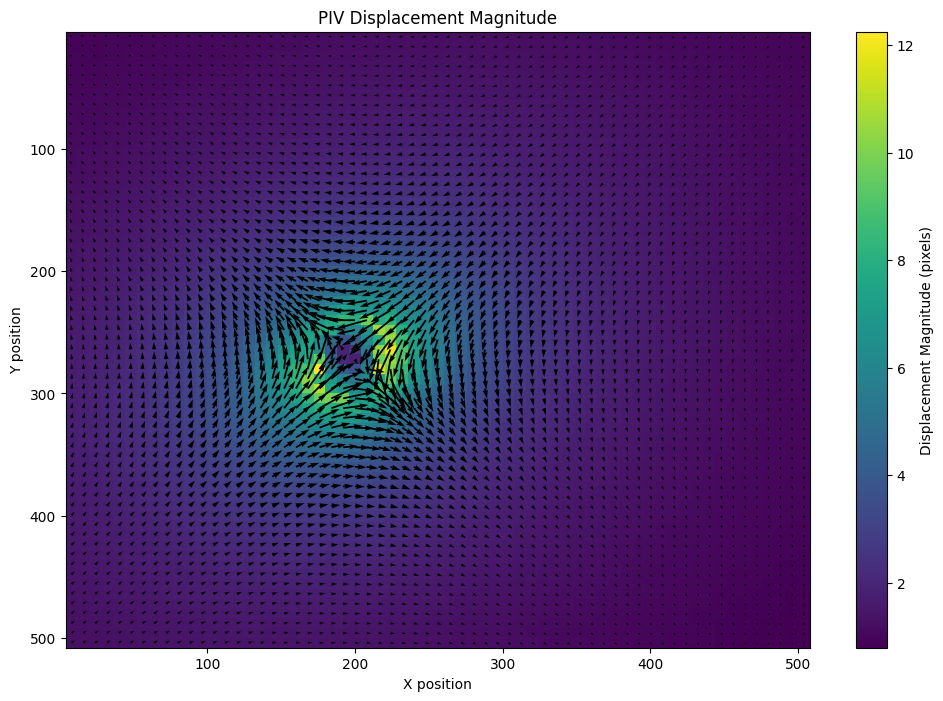

In [22]:
plt.figure(figsize=(12, 8))

# Background represents how large the displacement is
plt.pcolormesh(
    x,
    y,
    magnitude,
    shading="auto"
)

# Add a scale explaining the magnitude values
plt.colorbar(
    label="Displacement Magnitude (pixels)"
)

# Draw the direction vectors on top
plt.quiver(
    x,
    y,
    u,
    v
)

plt.gca().invert_yaxis()

plt.title("PIV Displacement Magnitude")
plt.xlabel("X position")
plt.ylabel("Y position")

plt.show()

In [23]:
# Convert u into a masked NumPy array
u_masked = np.ma.array(
    u,
    mask=np.zeros_like(u, dtype=bool)
)

# Convert v into a masked NumPy array
v_masked = np.ma.array(
    v,
    mask=np.zeros_like(v, dtype=bool)
)

In [24]:
# Compare every vector against its nearby neighbors

flags = validation.local_median_val(
    u_masked,
    v_masked,

    # How different horizontal movement can be
    # before we consider it suspicious
    u_threshold=2,

    # Same idea for vertical movement
    v_threshold=2,

    # Look at the immediate neighborhood
    size=1
)

# Count how many vectors were flagged
invalid_vectors = np.sum(flags)

# Count total vectors
total_vectors = flags.size

# Calculate percentage flagged
percent_invalid = (
    invalid_vectors / total_vectors
) * 100


print("Flagged vectors:", invalid_vectors)
print("Total vectors:", total_vectors)
print("Percent flagged:", percent_invalid)

Flagged vectors: 10
Total vectors: 3969
Percent flagged: 0.25195263290501385


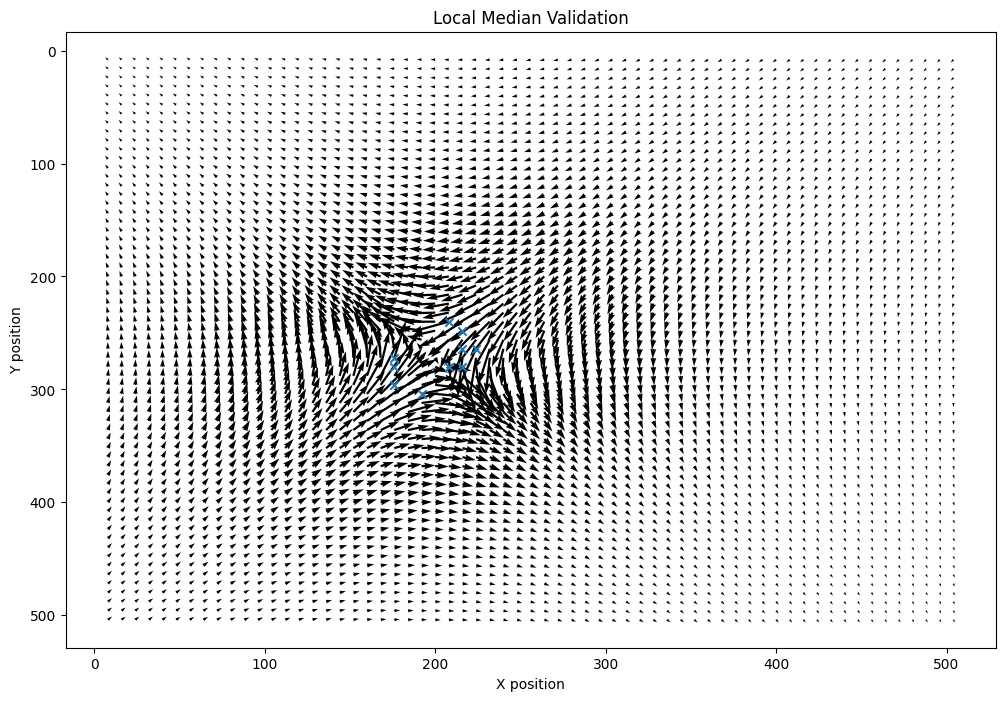

In [25]:
plt.figure(figsize=(12, 8))

# Show every PIV vector
plt.quiver(
    x,
    y,
    u,
    v
)

# Put an X on vectors flagged by validation
plt.scatter(
    x[flags],
    y[flags],
    marker="x"
)

plt.gca().invert_yaxis()

plt.title("Local Median Validation")
plt.xlabel("X position")
plt.ylabel("Y position")

plt.show()